# Radar Data Analysis
## Visualization of radar parameters over time

This notebook loads CSV files with radar data and plots each parameter as a function of time.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)

## Load Data

In [9]:
# Get current directory
data_dir = os.getcwd()
print(f"Looking for CSV files in: {data_dir}")

# Find latest CSV files for each parameter
parameters = ['rcs', 'velocity', 'x', 'y', 'z', 'snr']
data = {}

for param in parameters:
    files = glob.glob(os.path.join(data_dir, f'*{param}_*.csv'))
    if files:
        # Get most recent file
        latest_file = max(files, key=os.path.getmtime)
        df = pd.read_csv(latest_file)
        # Convert timestamp to relative time
        if len(df) > 0:
            df['time_relative'] = df['timestamp'] - df['timestamp'].iloc[0]
            data[param] = df
            print(f"{param}: {len(df)} points, {os.path.basename(latest_file)}")

print(f"\nLoaded {len(data)} parameters")

Looking for CSV files in: /home/dmitrytorov/hd_radar_ros2_1_2_0/src/path_tracker/analys
rcs: 136 points, radar_data_rcs_20251009_145219.csv
x: 136 points, radar_data_x_20251009_145219.csv
y: 136 points, radar_data_y_20251009_145219.csv
z: 136 points, radar_data_z_20251009_145219.csv
snr: 136 points, radar_data_snr_20251009_145219.csv

Loaded 5 parameters


## Plot All Parameters

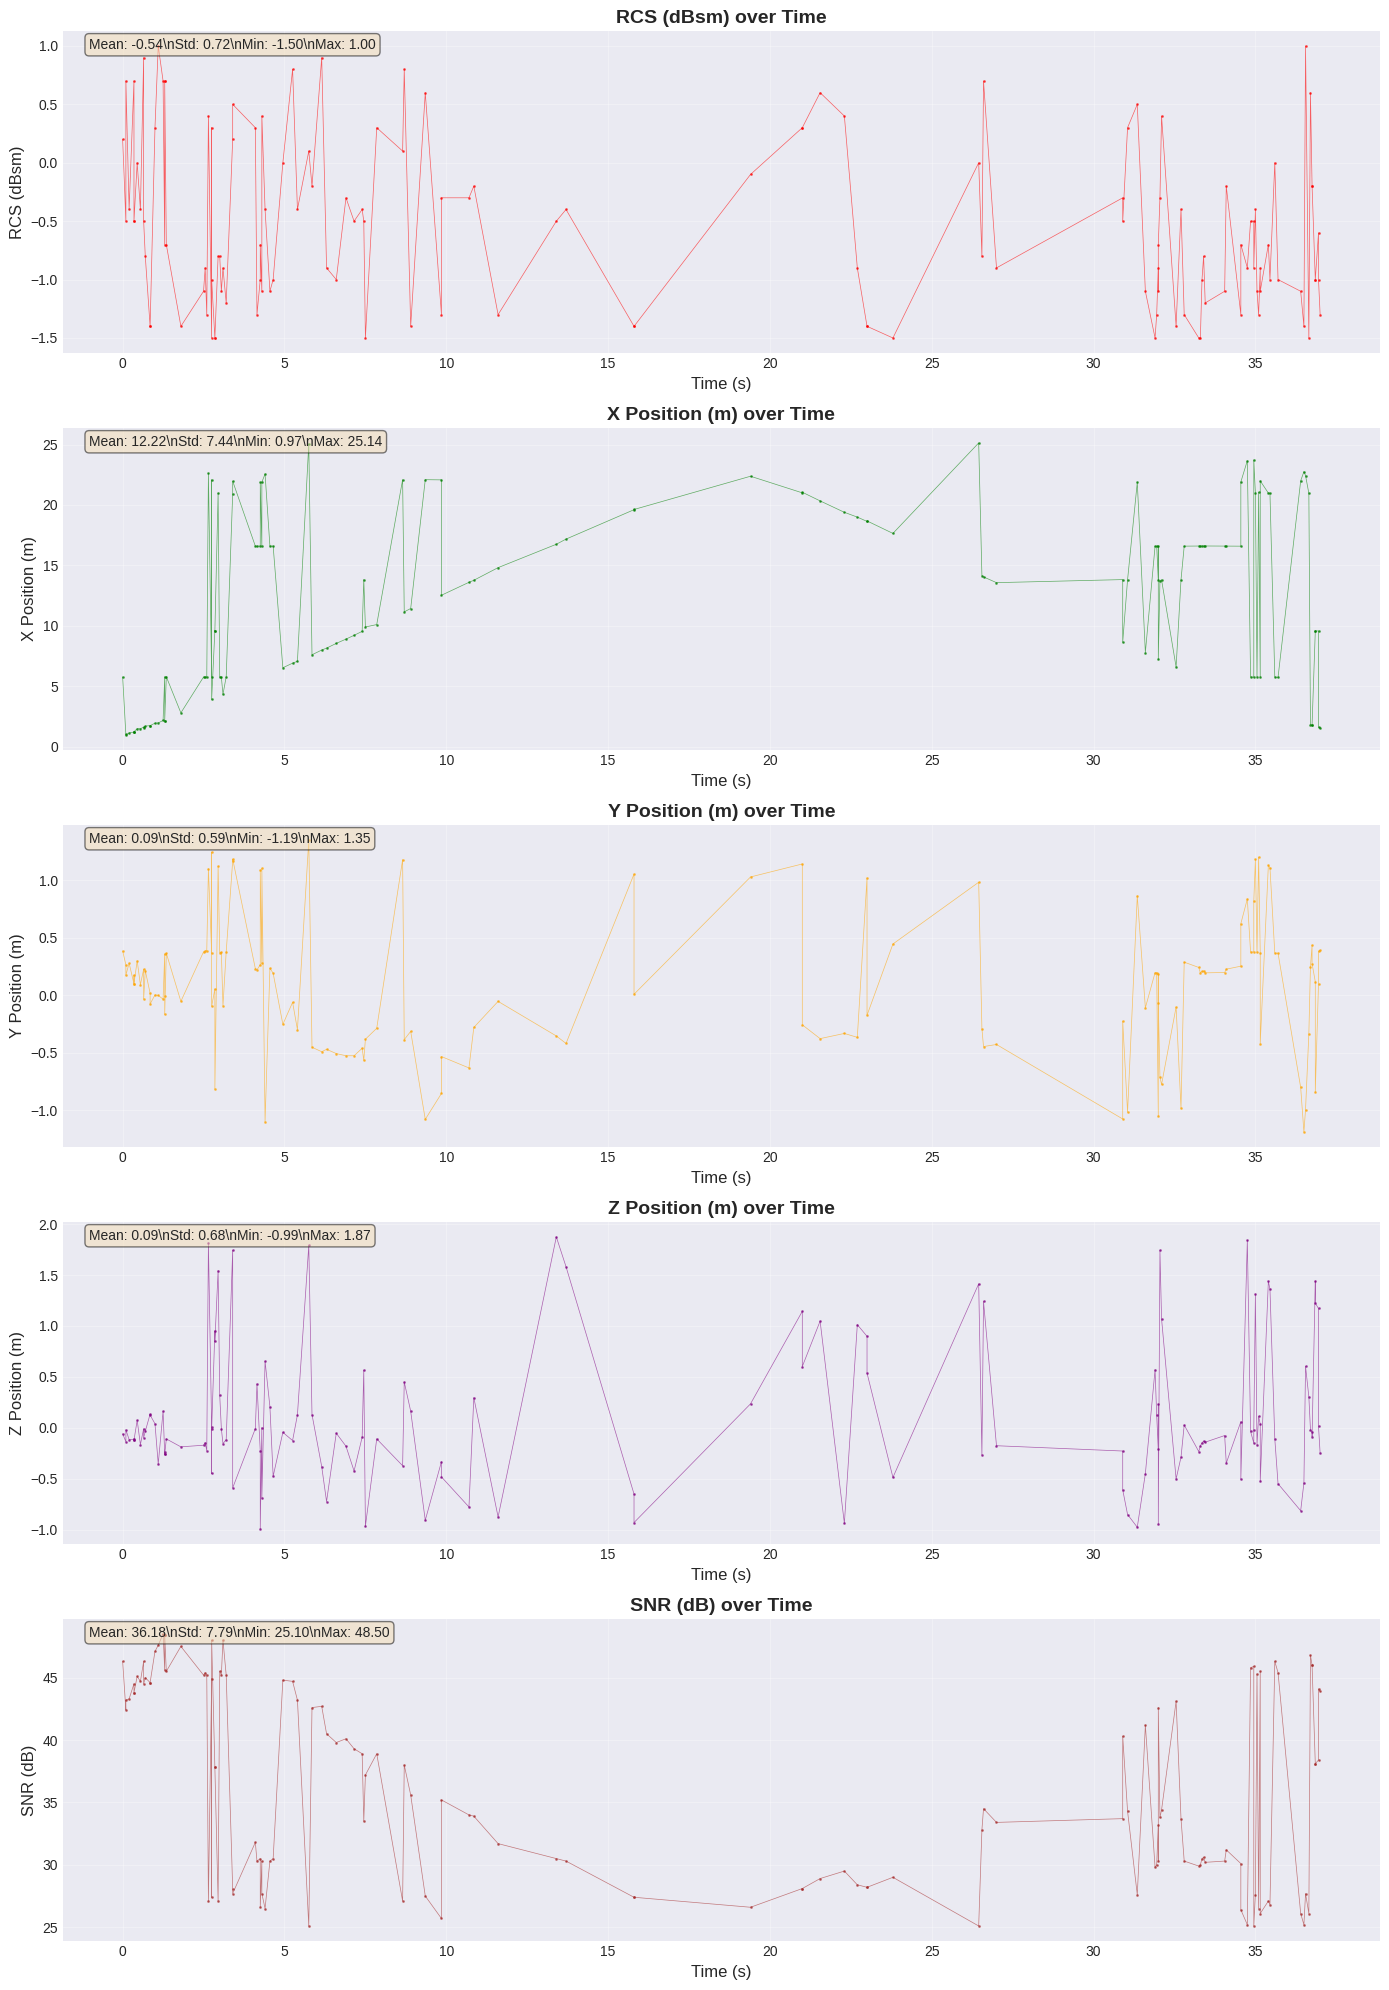

In [10]:
# Parameter info for plotting
param_info = {
    'rcs': {'label': 'RCS (dBsm)', 'color': 'red'},
    'velocity': {'label': 'Velocity (m/s)', 'color': 'blue'},
    'x': {'label': 'X Position (m)', 'color': 'green'},
    'y': {'label': 'Y Position (m)', 'color': 'orange'},
    'z': {'label': 'Z Position (m)', 'color': 'purple'},
    'snr': {'label': 'SNR (dB)', 'color': 'brown'}
}

# Create subplots
if data:
    fig, axes = plt.subplots(len(data), 1, figsize=(14, 4*len(data)))
    if len(data) == 1:
        axes = [axes]
    
    for idx, (param, df) in enumerate(data.items()):
        ax = axes[idx]
        info = param_info[param]
        
        ax.plot(df['time_relative'], df[param], 
                color=info['color'], alpha=0.6, linewidth=0.5, marker='.', markersize=2)
        
        ax.set_xlabel('Time (s)', fontsize=12)
        ax.set_ylabel(info['label'], fontsize=12)
        ax.set_title(f"{info['label']} over Time", fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Stats
        stats = f"Mean: {df[param].mean():.2f}\\nStd: {df[param].std():.2f}\\nMin: {df[param].min():.2f}\\nMax: {df[param].max():.2f}"
        ax.text(0.02, 0.98, stats, transform=ax.transAxes, fontsize=10, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

## RCS Analysis

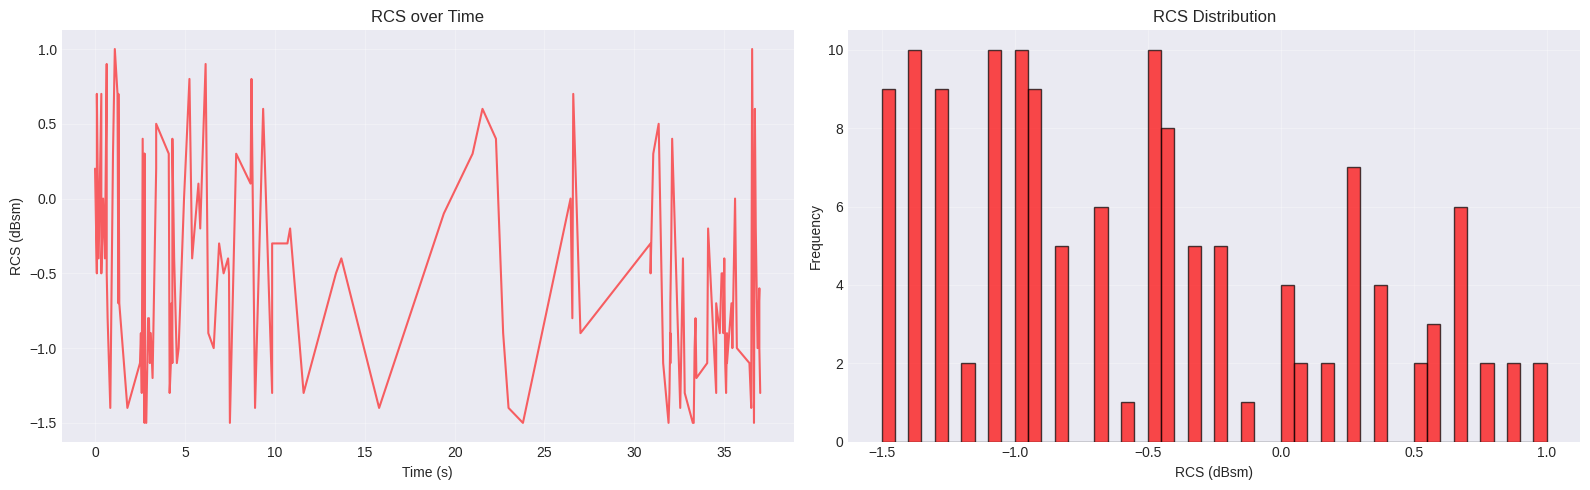

In [11]:
if 'rcs' in data:
    df = data['rcs']
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    ax1.plot(df['time_relative'], df['rcs'], color='red', alpha=0.6)
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('RCS (dBsm)')
    ax1.set_title('RCS over Time')
    ax1.grid(True, alpha=0.3)
    
    ax2.hist(df['rcs'], bins=50, color='red', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('RCS (dBsm)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('RCS Distribution')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Velocity Analysis

In [15]:
if 'velocity' in data:
    df = data['velocity']
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    ax1.plot(df['time_relative'], df['velocity'], color='blue', alpha=0.6)
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Velocity (m/s)')
    ax1.set_title('Velocity over Time')
    ax1.grid(True, alpha=0.3)
    
    ax2.hist(df['velocity'], bins=50, color='blue', alpha=0.7, edgecolor='black')
    ax2.axvline(x=0, color='black', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Velocity (m/s)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Velocity Distribution')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 3D Position (X, Y, Z)

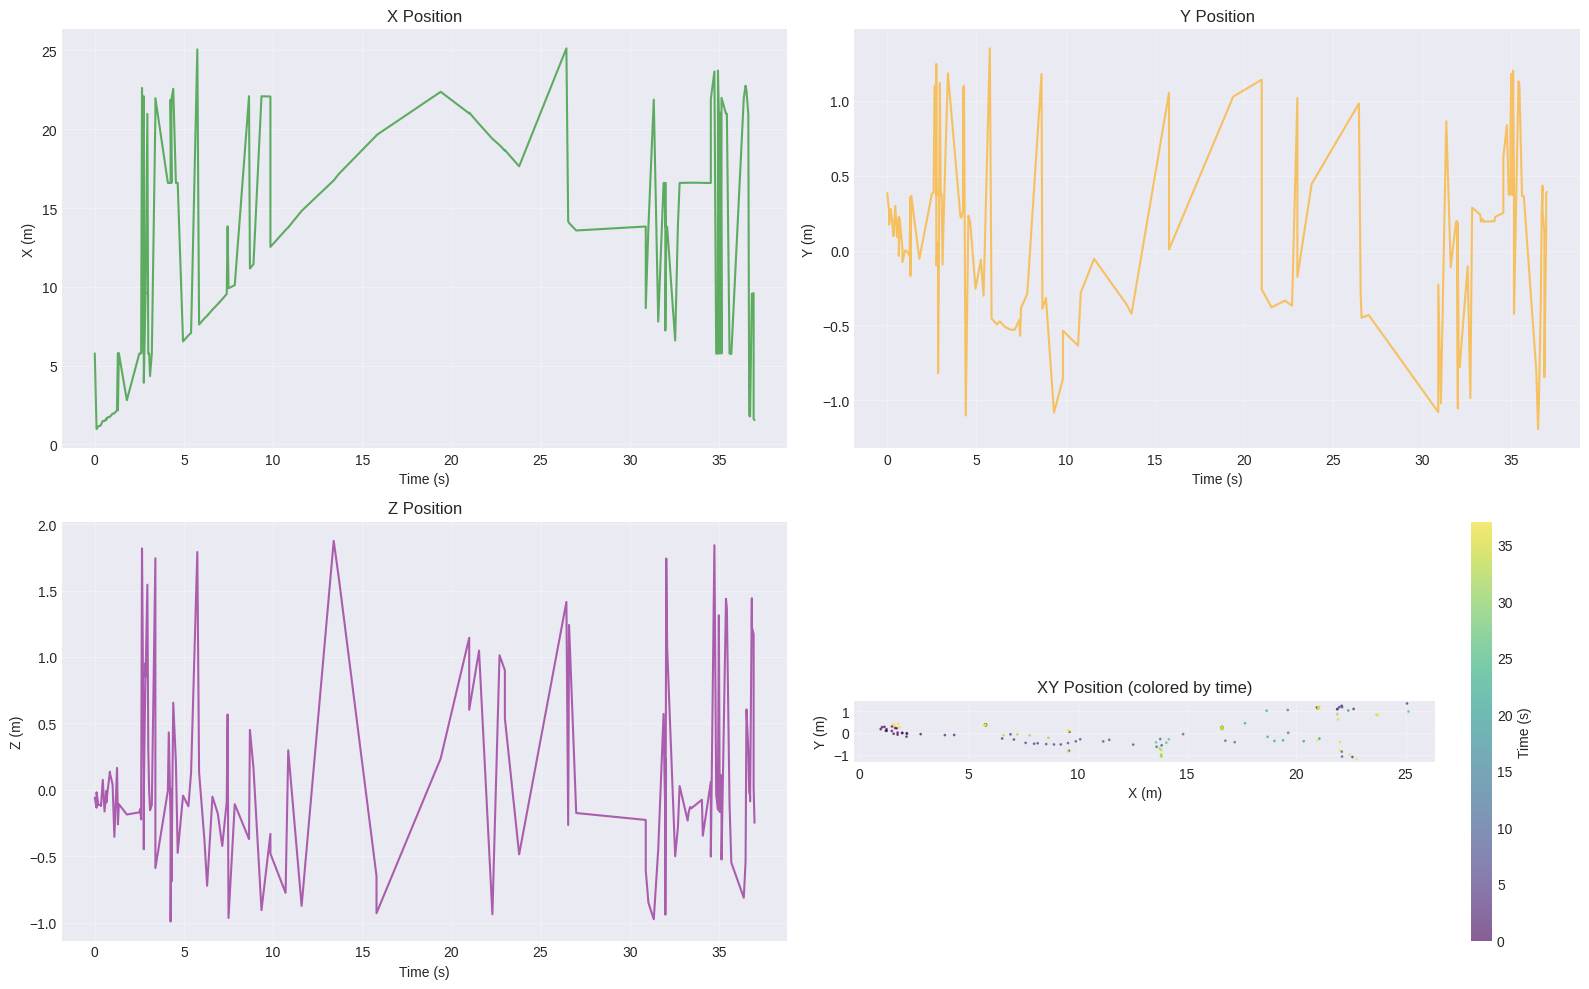

In [16]:
if all(p in data for p in ['x', 'y', 'z']):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    axes[0,0].plot(data['x']['time_relative'], data['x']['x'], 'g-', alpha=0.6)
    axes[0,0].set_xlabel('Time (s)')
    axes[0,0].set_ylabel('X (m)')
    axes[0,0].set_title('X Position')
    axes[0,0].grid(True, alpha=0.3)
    
    axes[0,1].plot(data['y']['time_relative'], data['y']['y'], color='orange', alpha=0.6)
    axes[0,1].set_xlabel('Time (s)')
    axes[0,1].set_ylabel('Y (m)')
    axes[0,1].set_title('Y Position')
    axes[0,1].grid(True, alpha=0.3)
    
    axes[1,0].plot(data['z']['time_relative'], data['z']['z'], color='purple', alpha=0.6)
    axes[1,0].set_xlabel('Time (s)')
    axes[1,0].set_ylabel('Z (m)')
    axes[1,0].set_title('Z Position')
    axes[1,0].grid(True, alpha=0.3)
    
    sc = axes[1,1].scatter(data['x']['x'], data['y']['y'], 
                           c=data['x']['time_relative'], cmap='viridis', alpha=0.6, s=1)
    axes[1,1].set_xlabel('X (m)')
    axes[1,1].set_ylabel('Y (m)')
    axes[1,1].set_title('XY Position (colored by time)')
    axes[1,1].set_aspect('equal')
    axes[1,1].grid(True, alpha=0.3)
    plt.colorbar(sc, ax=axes[1,1], label='Time (s)')
    
    plt.tight_layout()
    plt.show()

## Data Statistics

In [14]:
if data:
    summary = {}
    for param, df in data.items():
        summary[param] = {
            'Count': len(df),
            'Mean': df[param].mean(),
            'Std': df[param].std(),
            'Min': df[param].min(),
            'Max': df[param].max(),
            'Median': df[param].median()
        }
    
    summary_df = pd.DataFrame(summary).T
    print("RADAR DATA SUMMARY STATISTICS")
    print("="*80)
    print(summary_df.to_string())
    print("="*80)

RADAR DATA SUMMARY STATISTICS
     Count       Mean       Std     Min     Max   Median
rcs  136.0  -0.541176  0.716108  -1.500   1.000  -0.7000
x    136.0  12.216949  7.444693   0.967  25.135  13.6705
y    136.0   0.085654  0.590702  -1.191   1.349   0.1730
z    136.0   0.087559  0.684315  -0.992   1.874  -0.0890
snr  136.0  36.175000  7.786044  25.100  48.500  34.3500
